<a href="https://colab.research.google.com/github/yawarabbasmalik/Key-Indicators-of-Heart-Disease/blob/main/Heart_Failure_Clinical_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.optimizers import Adam

In [ ]:
# Load the dataset
heart_failure_data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# Getting the size of the dataset
dataset_size = heart_failure_data.shape

# Getting the types of variables
variables_types = heart_failure_data.dtypes

# Checking for missing data
missing_data = heart_failure_data.isnull().sum()

In [ ]:
dataset_size

(299, 13)

The dataset contains 299 records and 13 features. Here are the types of variables and a brief description for each:

In [ ]:
variables_types

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

- age: (float64) Numerical variable indicating the age of the patient.
- anaemia: (int64) Binary variable indicating the presence or absence of anaemia (0 = no, 1 = yes).
- creatinine_phosphokinase: (int64) Numerical variable indicating the level of the CPK enzyme in the blood (mcg/L).
- diabetes: (int64) Binary variable indicating whether the patient has diabetes (0 = no, 1 = yes).
- ejection_fraction: (int64) Numerical variable indicating the percentage of blood leaving the heart at each contraction.
- high_blood_pressure: (int64) Binary variable indicating if the patient has hypertension (0 = no, 1 = yes).
- platelets: (float64) Numerical variable indicating the number of platelets in the blood (kiloplatelets/mL).
- serum_creatinine: (float64) Numerical variable indicating the level of serum creatinine in the blood (mg/dL).
- serum_sodium: (int64) Numerical variable indicating the level of serum sodium in the blood (mEq/L).
- sex: (int64) Binary variable indicating the gender of the patient (0 = female, 1 = male).
- smoking: (int64) Binary variable indicating whether the patient smokes (0 = no, 1 = yes).
- time: (int64) Numerical variable indicating the follow-up period (days).
- DEATH_EVENT: (int64) Binary target variable indicating if the patient deceased during the follow-up period (0 = no, 1 = yes).

In [ ]:
missing_data

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

There are no missing values in the dataset, so no cleaning with respect to missing data is required. The dataset appears to be clean and ready for analysis or model building.​​

## Descriptive Analysis

For the descriptive statistical analysis, we can start by looking at the summary statistics of the numerical variables. Then, we will visualize the distribution of a selection of both numerical and categorical variables using bar plots and pie charts. Finally, we'll examine dependencies between variables using grouped bar plots.

In [ ]:
# Summary statistics for the numerical variables
numerical_variables_summary = heart_failure_data.describe()

numerical_variables_summary


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


The summary statistics for the numerical variables are as follows:

- age: The average age in the dataset is approximately 60.83 years, with a standard deviation of 11.89 years. The age range is from 40 to 95 years.
- creatinine_phosphokinase: The enzyme level varies widely among patients, with a mean of 581.84 mcg/L and a standard deviation of 970.29 mcg/L. The values range from 23 mcg/L to 7861 mcg/L, suggesting high variability among the patients.
- ejection_fraction: On average, the ejection fraction is 38.08%, with a standard deviation of 11.83%. This measure ranges from 14% to 80%.
- platelets: The average platelet count is about 263,358 per microliter of blood, with a standard deviation of 97,804. The count ranges from 25,100 to 850,000.
- serum_creatinine: The mean serum creatinine level is 1.39 mg/dL, with a standard deviation of 1.03 mg/dL. The levels range from 0.5 mg/dL to 9.4 mg/dL.
- serum_sodium: The mean serum sodium level is 136.63 mEq/L, with a standard deviation of 4.41 mEq/L. Levels range from 113 mEq/L to 148 mEq/L.

## Visualization

Next, let's visualize some of the categorical variables (anaemia, diabetes, high_blood_pressure, sex, smoking, and the target variable DEATH_EVENT) using bar plots and pie charts to see their frequencies, and then we'll look at a grouped bar plot to explore dependencies between some of these variables and the target variable.​

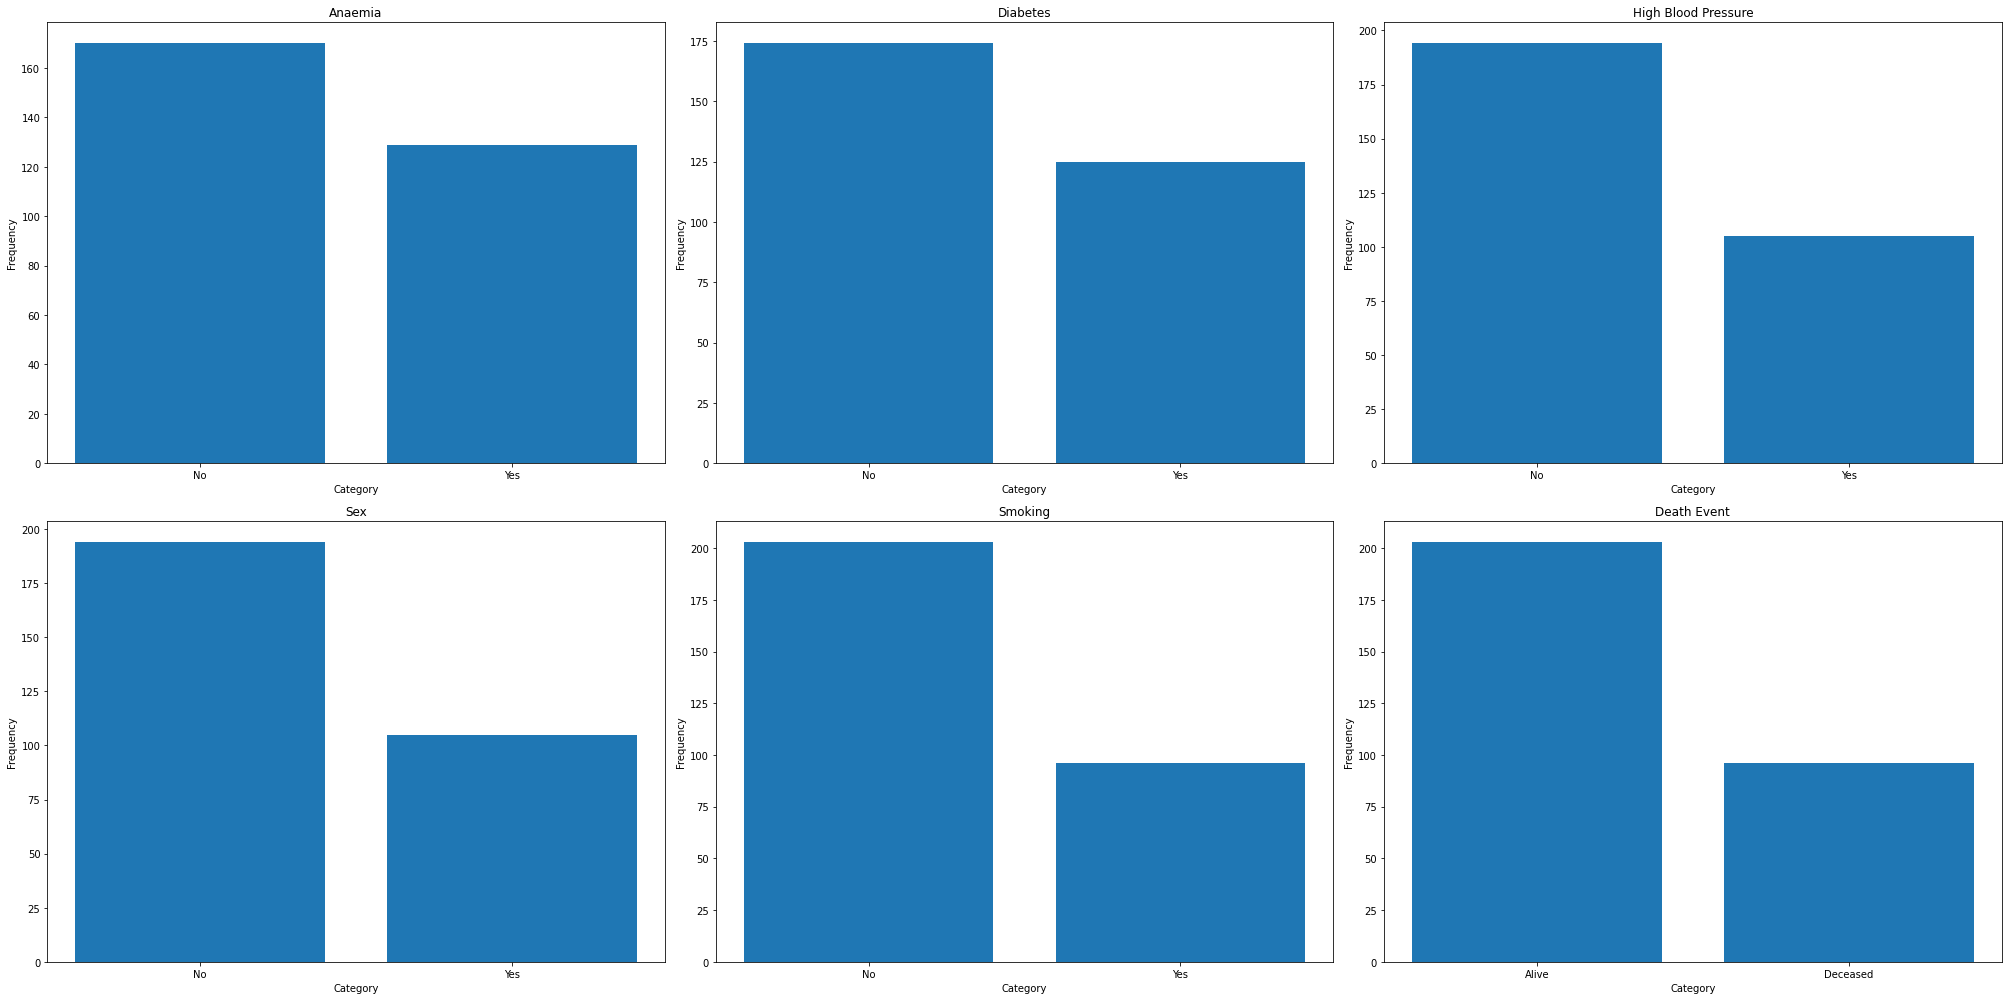

In [ ]:
# Set up the matplotlib figure size
plt.rcParams["figure.figsize"] = (28, 14)

# Subplot for the categorical variables
fig, ax = plt.subplots(2, 3)

# Variables to plot
categorical_variables = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']
titles = ['Anaemia', 'Diabetes', 'High Blood Pressure', 'Sex', 'Smoking', 'Death Event']

# Create bar plot for each categorical variable
for i, var in enumerate(categorical_variables):
    # Find the frequency of each category
    freq = heart_failure_data[var].value_counts()
    # Plot
    ax[i//3, i%3].bar(freq.index.astype(str), freq.values)
    ax[i//3, i%3].set_title(titles[i])
    ax[i//3, i%3].set_xticks(freq.index.astype(str))
    ax[i//3, i%3].set_xticklabels(['No', 'Yes'] if i < 5 else ['Alive', 'Deceased'])
    ax[i//3, i%3].set_xlabel('Category')
    ax[i//3, i%3].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


Here are the bar plots showing the frequencies of the categorical variables:

- Anaemia: The dataset contains a nearly equal distribution of patients with and without anaemia.
- Diabetes: A slightly lower number of patients have diabetes compared to those who do not.
- High Blood Pressure: Similar to diabetes, fewer patients have high blood pressure than those who do not.
- Sex: There are more male patients than female patients in this dataset.
- Smoking: The majority of patients do not smoke.
- Death Event: Fewer patients experienced a death event than those who did not, within the timeframe of the study.

Now, to explore dependencies between some of these variables and the target variable (DEATH_EVENT), we can use grouped bar plots. We'll look at the relationship between DEATH_EVENT and variables like anaemia, diabetes, high_blood_pressure, and smoking. Let's create those grouped bar plots next.​​



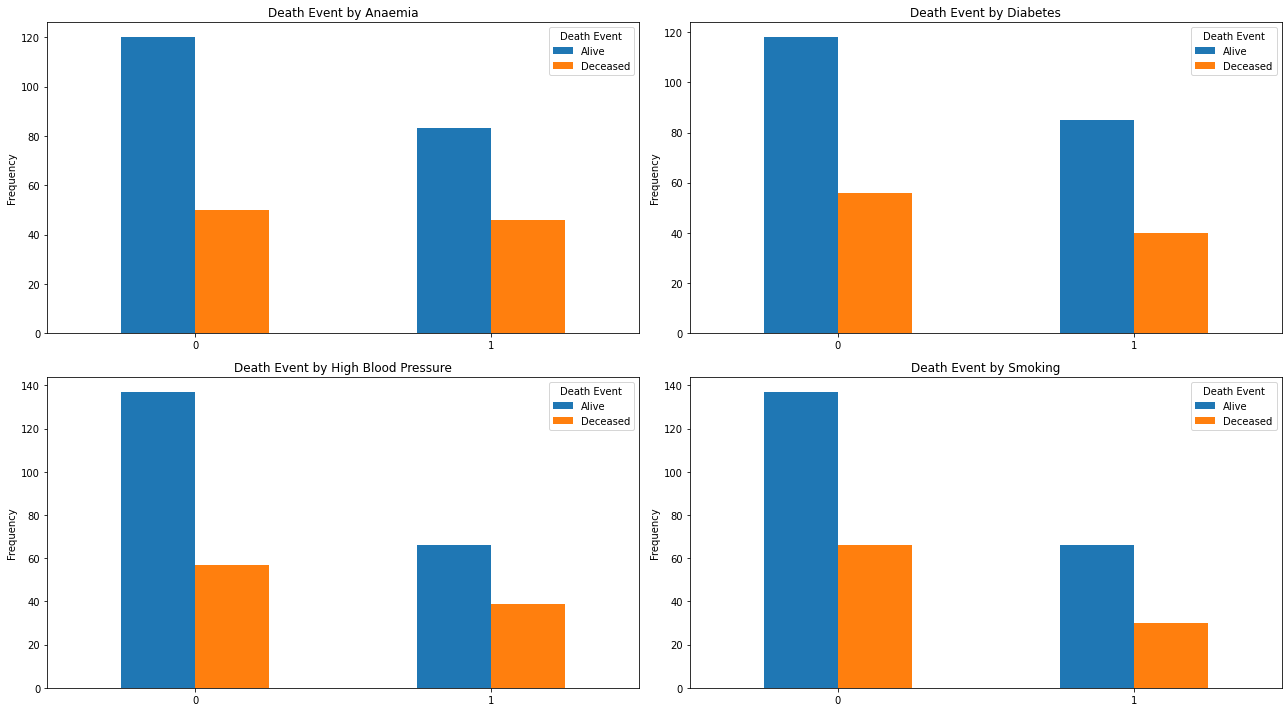

In [ ]:
# Set up the matplotlib figure size
plt.rcParams["figure.figsize"] = (18, 10)

# Subplot for the dependency grouped bar plots
fig, ax = plt.subplots(2, 2)

# Create grouped bar plot for each variable against the target variable
dependency_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']  # Selected variables
dependency_titles = ['Anaemia', 'Diabetes', 'High Blood Pressure', 'Smoking']

for i, var in enumerate(dependency_vars):
    # Get the cross tabulation of two variables
    crosstab = pd.crosstab(heart_failure_data[var], heart_failure_data['DEATH_EVENT'])
    # Plot
    crosstab.plot(kind='bar', ax=ax[i//2, i%2], color=['#1f77b4', '#ff7f0e'], rot=0)
    ax[i//2, i%2].set_title(f'Death Event by {dependency_titles[i]}')
    ax[i//2, i%2].set_xlabel('')
    ax[i//2, i%2].set_ylabel('Frequency')
    ax[i//2, i%2].legend(title='Death Event', labels=['Alive', 'Deceased'])

plt.tight_layout()
plt.show()


The grouped bar plots display the relationship between the occurrence of death events and the presence of anaemia, diabetes, high blood pressure, and smoking in the patients:

1. Anaemia: Patients with anaemia seem to have a slightly higher incidence of death events compared to those without anaemia.
2. Diabetes: There does not appear to be a significant difference in the rate of death events between patients with and without diabetes.
3. High Blood Pressure: Patients with high blood pressure show a higher rate of death events compared to those without.
4. Smoking: The rate of death events is similar between smokers and non-smokers, with non-smokers having a slightly higher incidence, which may be due to other factors since smoking alone is not a direct indicator of heart failure.

These visualizations help in understanding the individual impact of each condition on the mortality of the patients in the dataset.​

## Data Splitting

In [ ]:
# Assuming your DataFrame is named `heart_failure_data`
X = heart_failure_data.drop('DEATH_EVENT', axis=1)
y = heart_failure_data['DEATH_EVENT']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalize the feature data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Building the Neural Network Model

In [ ]:
# Define the model
model = Sequential([
    Dense(5, input_shape=(X_train_scaled.shape[1],), activation='relu'),  # First hidden layer with 5 neurons
    Dense(3, activation='relu'),  # Second hidden layer with 3 neurons
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


## Training the Model

In [ ]:
# Fit the model to the training data
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=10, verbose=1)


Epoch 1/100
21/21 [==============================] - 1s 2ms/step - loss: 0.7176 - accuracy: 0.3254
Epoch 2/100
21/21 [==============================] - 0s 2ms/step - loss: 0.7048 - accuracy: 0.4019
Epoch 3/100
21/21 [==============================] - 0s 3ms/step - loss: 0.6938 - accuracy: 0.5311
Epoch 4/100
21/21 [==============================] - 0s 2ms/step - loss: 0.6855 - accuracy: 0.6029
Epoch 5/100
21/21 [==============================] - 0s 2ms/step - loss: 0.6778 - accuracy: 0.6699
Epoch 6/100
21/21 [==============================] - 0s 2ms/step - loss: 0.6711 - accuracy: 0.7177
Epoch 7/100
21/21 [==============================] - 0s 2ms/step - loss: 0.6651 - accuracy: 0.7321
Epoch 8/100
21/21 [==============================] - 0s 2ms/step - loss: 0.6599 - accuracy: 0.7560
Epoch 9/100
21/21 [==============================] - 0s 2ms/step - loss: 0.6549 - accuracy: 0.7608
Epoch 10/100
21/21 [==============================] - 0s 2ms/step - loss: 0.6497 - accuracy: 0.7608
Epoch 11/

21/21 [==============================] - 0s 2ms/step - loss: 0.2463 - accuracy: 0.8947
Epoch 84/100
21/21 [==============================] - 0s 2ms/step - loss: 0.2444 - accuracy: 0.9043
Epoch 85/100
21/21 [==============================] - 0s 2ms/step - loss: 0.2433 - accuracy: 0.8995
Epoch 86/100
21/21 [==============================] - 0s 2ms/step - loss: 0.2410 - accuracy: 0.8995
Epoch 87/100
21/21 [==============================] - 0s 2ms/step - loss: 0.2405 - accuracy: 0.9091
Epoch 88/100
21/21 [==============================] - 0s 2ms/step - loss: 0.2385 - accuracy: 0.9091
Epoch 89/100
21/21 [==============================] - 0s 2ms/step - loss: 0.2373 - accuracy: 0.9187
Epoch 90/100
21/21 [==============================] - 0s 2ms/step - loss: 0.2350 - accuracy: 0.9187
Epoch 91/100
21/21 [==============================] - 0s 2ms/step - loss: 0.2340 - accuracy: 0.9187
Epoch 92/100
21/21 [==============================] - 0s 2ms/step - loss: 0.2335 - accuracy: 0.9187
Epoch 93/100


## Evaluating the Model

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test Accuracy: {accuracy*100:.2f}%')


3/3 [==============================] - 0s 2ms/step - loss: 0.6409 - accuracy: 0.7333
Test Accuracy: 73.33%


## Confusion Matrix

In [ ]:
# Predicting the Test set results
y_pred = model.predict(X_test_scaled)
y_pred = (y_pred > 0.5)  # Convert probabilities to binary output

# Making the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


3/3 [==============================] - 0s 2ms/step
[[46  7]
 [17 20]]


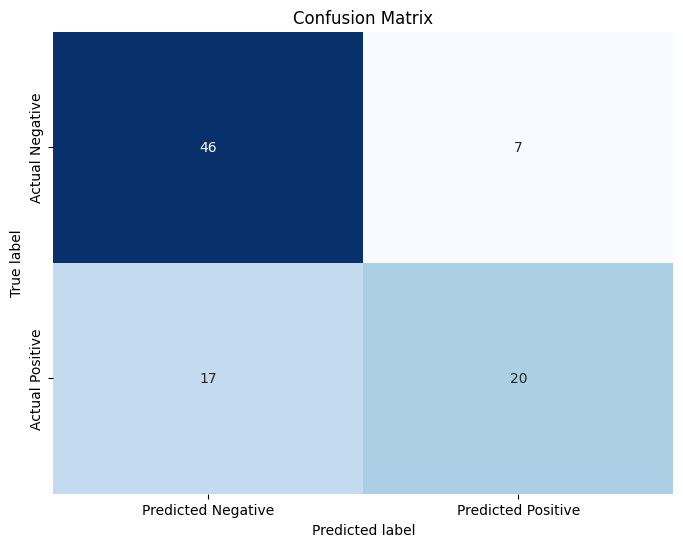

In [ ]:
# Assuming you have the confusion matrix data
cm_data = [[46, 7], [17, 20]]

# Convert the data into a pandas DataFrame
cm_df = pd.DataFrame(cm_data, index=['Actual Negative', 'Actual Positive'],
                     columns=['Predicted Negative', 'Predicted Positive'])

# Plot the confusion matrix using Seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


## New Deep Neural Network Model with Parameters Changing

In [ ]:
# Define the updated model
model_updated = Sequential([
    Dense(10, input_shape=(X_train_scaled.shape[1],), activation='tanh'),  # First hidden layer with 10 neurons
    Dense(6, activation='tanh'),  # Second hidden layer with 6 neurons
    Dense(4, activation='tanh'),  # Third hidden layer with 4 neurons
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the updated model with a custom learning rate
adam_custom = Adam(learning_rate=0.001)
model_updated.compile(optimizer=adam_custom, loss='binary_crossentropy', metrics=['accuracy'])

# Fit the updated model to the training data
history_updated = model_updated.fit(X_train_scaled, y_train, epochs=100, batch_size=10, verbose=1)

Epoch 1/100
21/21 [==============================] - 0s 2ms/step - loss: 0.7849 - accuracy: 0.5311
Epoch 2/100
21/21 [==============================] - 0s 1ms/step - loss: 0.7104 - accuracy: 0.5646
Epoch 3/100
21/21 [==============================] - 0s 2ms/step - loss: 0.6487 - accuracy: 0.6124
Epoch 4/100
21/21 [==============================] - 0s 2ms/step - loss: 0.6006 - accuracy: 0.6603
Epoch 5/100
21/21 [==============================] - 0s 2ms/step - loss: 0.5629 - accuracy: 0.7033
Epoch 6/100
21/21 [==============================] - 0s 2ms/step - loss: 0.5299 - accuracy: 0.7225
Epoch 7/100
21/21 [==============================] - 0s 2ms/step - loss: 0.5013 - accuracy: 0.7560
Epoch 8/100
21/21 [==============================] - 0s 2ms/step - loss: 0.4777 - accuracy: 0.7656
Epoch 9/100
21/21 [==============================] - 0s 2ms/step - loss: 0.4552 - accuracy: 0.7895
Epoch 10/100
21/21 [==============================] - 0s 2ms/step - loss: 0.4357 - accuracy: 0.7847
Epoch 11/

21/21 [==============================] - 0s 2ms/step - loss: 0.1614 - accuracy: 0.9569
Epoch 84/100
21/21 [==============================] - 0s 2ms/step - loss: 0.1599 - accuracy: 0.9474
Epoch 85/100
21/21 [==============================] - 0s 2ms/step - loss: 0.1565 - accuracy: 0.9617
Epoch 86/100
21/21 [==============================] - 0s 2ms/step - loss: 0.1543 - accuracy: 0.9617
Epoch 87/100
21/21 [==============================] - 0s 2ms/step - loss: 0.1516 - accuracy: 0.9617
Epoch 88/100
21/21 [==============================] - 0s 2ms/step - loss: 0.1495 - accuracy: 0.9569
Epoch 89/100
21/21 [==============================] - 0s 3ms/step - loss: 0.1462 - accuracy: 0.9617
Epoch 90/100
21/21 [==============================] - 0s 2ms/step - loss: 0.1458 - accuracy: 0.9617
Epoch 91/100
21/21 [==============================] - 0s 2ms/step - loss: 0.1419 - accuracy: 0.9617
Epoch 92/100
21/21 [==============================] - 0s 2ms/step - loss: 0.1399 - accuracy: 0.9665
Epoch 93/100


In [ ]:
# Evaluate the updated model on the test data
loss_updated, accuracy_updated = model_updated.evaluate(X_test_scaled, y_test)
print(f'Updated Test Accuracy: {accuracy_updated*100:.2f}%')

3/3 [==============================] - 0s 3ms/step - loss: 0.7322 - accuracy: 0.8000
Updated Test Accuracy: 80.00%


In [ ]:
# Predicting the Test set results
y_pred_updated = model_updated.predict(X_test_scaled)
y_pred_updated = (y_pred_updated > 0.5)

# Making the Confusion Matrix
cm_updated = confusion_matrix(y_test, y_pred_updated)
print(cm_updated)


3/3 [==============================] - 0s 2ms/step
[[48  5]
 [13 24]]


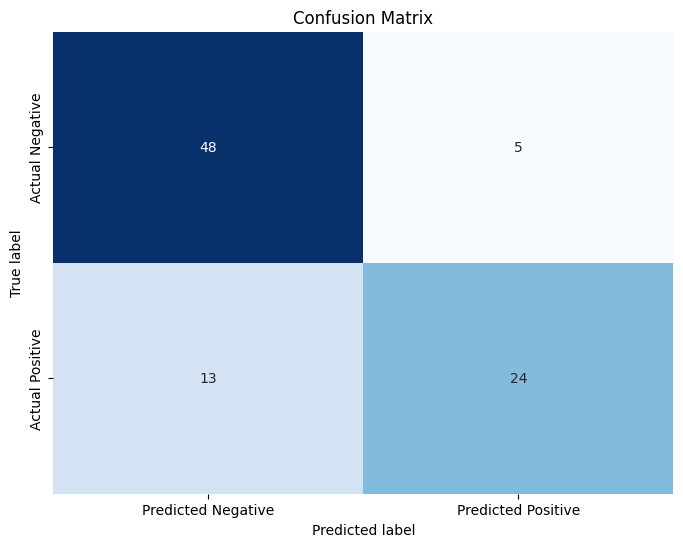

In [ ]:
# Assuming you have the confusion matrix data
cm_data = [[48, 5], [13, 24]]

# Convert the data into a pandas DataFrame
cm_df = pd.DataFrame(cm_data, index=['Actual Negative', 'Actual Positive'],
                     columns=['Predicted Negative', 'Predicted Positive'])

# Plot the confusion matrix using Seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


## Comparitive Analysis

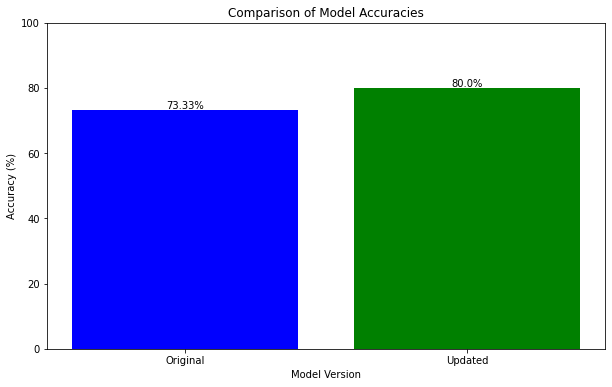

In [ ]:
# Accuracy values
accuracies = [73.33, 80.00]
model_versions = ['Original', 'Updated']

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(model_versions, accuracies, color=['blue', 'green'])

# Add title and labels
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model Version')
plt.ylabel('Accuracy (%)')

# Display the values on the bars
for i in range(len(accuracies)):
    plt.text(i, accuracies[i] + 0.5, f"{accuracies[i]}%", ha = 'center')

# Show the plot
plt.ylim(0, 100)  # Set y-axis range to show percentages clearly
plt.show()
